In [29]:
import numpy as np
def exponential_moving_average(data, alpha=0.1):
    ema = []
    for i, v in enumerate(data):
        if i == 0:
            ema.append(v)
        else:
            ema.append(alpha * v + (1 - alpha) * ema[-1])
    return ema


def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [1374.0, 1591.0, 1599.0, 1551.0, 1517.0, 1765.0, 1662.0, 1491.0, 1523

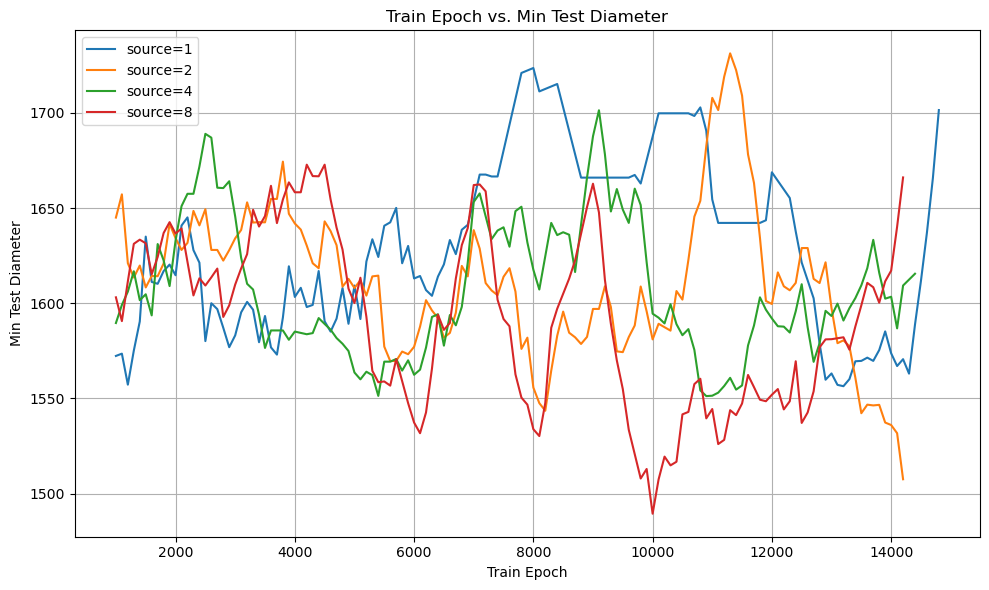

In [37]:
import re
import os
import matplotlib.pyplot as plt

def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    min_diameter_list = [float(m[1]) for m in matches]

    return epoch_list, min_diameter_list


    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # best_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))
for label, (epochs, diameters) in log_data.items():
    # plt.plot(epochs, diameters, label=label)
    smoothed_loss = moving_average(diameters, window_size=10)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [77924.4141, 57243.0391, 76600.7266, 78620.9297, 148461.7812, 3014785

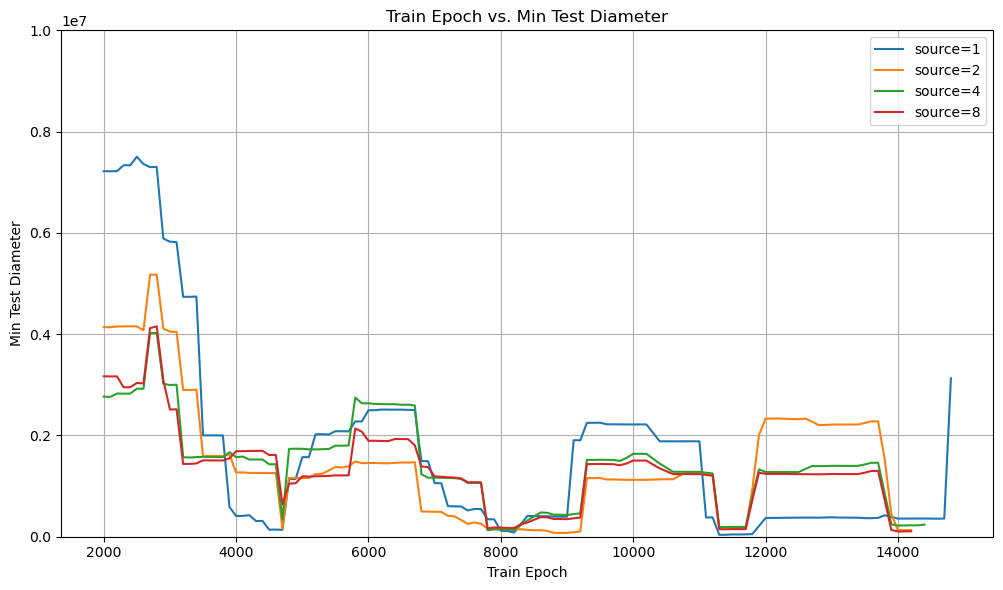

In [35]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np


def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # min_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, min_diameter_list
    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?loss\s*=\s*([\d\.eE\+\-]+)",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    loss = [float(m[1]) for m in matches]

    return epoch_list, loss

    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # best_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))

for label, (epochs, diameters) in log_data.items():
    # ema_loss = exponential_moving_average(diameters, alpha=0.1)
    smoothed_loss = moving_average(diameters, window_size=20)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim([0, 1e7])
plt.show()

([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800], [1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374.0, 1374

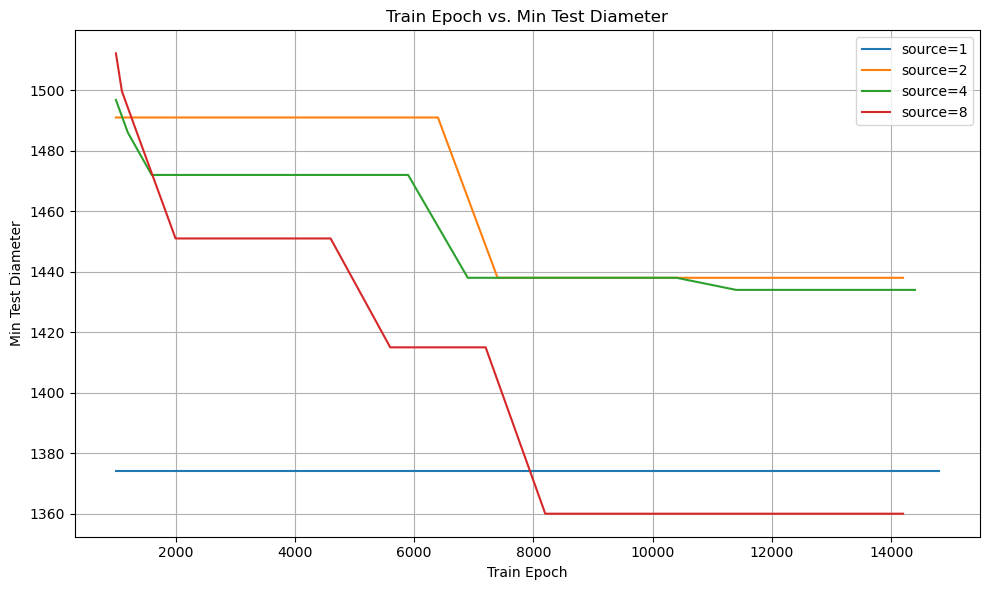

In [36]:
import re
import os
import matplotlib.pyplot as plt

def parse_flat_log_text(file):
    with open(file, 'r') as f:
        text = f.read()
    # Match all occurrences of (Epoch, Min Test Diameter)
    # pattern = re.compile(
    #     r"Train Epoch\s+(\d+)\s*:.*?Min Test Diameter\[(\d+\.?\d*)\]",
    #     re.DOTALL
    # )
    # matches = pattern.findall(text)

    # epoch_list = [int(m[0]) for m in matches]
    # min_diameter_list = [float(m[1]) for m in matches]

    # return epoch_list, min_diameter_list


    pattern = re.compile(
        r"Train Epoch\s+(\d+)\s*:.*?Best Test Diameter\s*(\d+\.?\d*)",
        re.DOTALL
    )
    matches = pattern.findall(text)

    epoch_list = [int(m[0]) for m in matches]
    best_diameter_list = [float(m[1]) for m in matches]

    return epoch_list, best_diameter_list

# Parse log from the provided path
log_path_1 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153331/output"
log_path_2 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153334/output"
log_path_4 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153410/output"
log_path_8 = "/pscratch/sd/s/swu264/SWARM/model/20250609_153420/output"

# Dummy placeholders (user will upload files)
log_data = {
    'source=1': ([], []),
    'source=2': ([], []),
    'source=4': ([], []),
    'source=8': ([], [])
}

# We will now wait for user to upload the actual log files
log_data['source=1'] = parse_flat_log_text(log_path_1)
log_data['source=2'] = parse_flat_log_text(log_path_2)
log_data['source=4'] = parse_flat_log_text(log_path_4)
log_data['source=8'] = parse_flat_log_text(log_path_8)
print(log_data['source=1'])
# assert 0
# Plotting
plt.figure(figsize=(10, 6))
for label, (epochs, diameters) in log_data.items():
    # plt.plot(epochs, diameters, label=label)
    smoothed_loss = moving_average(diameters, window_size=10)
    smoothed_epochs = epochs[len(epochs) - len(smoothed_loss):]
    # plt.plot(epoch_list, ema_loss)
    # plt.plot(epochs, ema_loss, label=label)
    plt.plot(smoothed_epochs, smoothed_loss, label=label)

plt.xlabel("Train Epoch")
plt.ylabel("Min Test Diameter")
plt.title("Train Epoch vs. Min Test Diameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# num_source=1
diameter mean=1235.0999755859375, std=89.98944091796875, min=1117.0, max=1412.0
Max Test Diameter [1412.0]
Min Test Diameter [1117.0]

# num_source=2
diameter mean=1346.9000244140625, std=89.84981536865234, min=1233.0, max=1475.0
Max Test Diameter [1475.0]
Min Test Diameter [1233.0]

# num_source=4
diameter mean=1372.4000244140625, std=125.71590423583984, min=1213.0, max=1683.0
Max Test Diameter [1683.0]
Min Test Diameter [1213.0]

# num_source=8
diameter mean=1429.800048828125, std=389.6253967285156, min=1194.0, max=2518.0
Max Test Diameter [2518.0]
Min Test Diameter [1194.0]